<a href="https://colab.research.google.com/github/rahiakela/transformers-research-and-practice/blob/main/build-reasoning-model-from-scratch/03-improving-reasoning-models/01_improving_reasoning_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chapter 4: Improving Reasoning with Inference-Time Scaling

Packages that are being used in this notebook:

In [1]:
!git clone --depth 1 https://github.com/rasbt/reasoning-from-scratch.git

Cloning into 'reasoning-from-scratch'...
remote: Enumerating objects: 258, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (231/231), done.
remote: Total 258 (delta 45), reused 125 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (258/258), 1.43 MiB | 17.02 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [2]:
!mkdir -p rm_from_scratch
!cp -r reasoning-from-scratch/reasoning_from_scratch/* rm_from_scratch

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F01_raschka.webp" width=600>

&nbsp;
## 4.1 Introduction to inference-time scaling

In general, there are two main strategies to improve reasoning:

1. Increasing training compute and
2. increasing inference compute (also known as inference-time scaling or test-time scaling).

We improve reasoning either by increasing
training-time compute or inference-time compute. LLMs are usually designed to improve
reasoning by combining heavy training-time compute and
increased inference-time compute.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F02_raschka.webp" width=600>

There are three practical and foundational inference-time techniques:

**Method 1**: Extending the chain-of-thought response to prompt the model to explain its reasoning. This is a simple technique that can substantially improve accuracy.

**Method 2**: Parallel sampling via self-consistency, where the model generates multiple responses and selects the most frequent one.

**Method 3**: Iterative self-refinement, where the model reviews and improves its own reasoning and answers across multiple steps.

- Plot above inspired by OpenAI o1 blog post, https://openai.com/index/learning-to-reason-with-llms/

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F03_raschka.webp" width=600>

- All 3 methods more than double the accuracy of the base model on MATH-500 (the benchmark from the prev. chapter)
- Methods 1 and 2 are covered in this chapter; method 3 is covered in the next chapter

&nbsp;
## 4.2 Loading a pre-trained model

- Model loading code similar to chapters 2 and 3

In [3]:
import torch
from rm_from_scratch.ch02 import get_device
from rm_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()

# Use CPU for the first run of this chapter
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using NVIDIA CUDA GPU
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


- Let's try the model on a prompt from the MATH-500 dataset, which we worked with in the previous chapter:

In [4]:
from rm_from_scratch.ch03 import render_prompt

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


- The following function is based on `generate_text_stream_concat` from the previous chapter, but we modify it slightly to be able to pass in other `generate_*` functions later

In [5]:
from rm_from_scratch.ch02 import generate_text_basic_stream_cache


def generate_text_stream_concat_flex(
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False,
    generate_func=None,  # New
    **generate_kwargs  # New
):

    if generate_func is None:  # New
        generate_func = generate_text_basic_stream_cache

    input_ids = torch.tensor(
        tokenizer.encode(prompt), device=device
        ).unsqueeze(0)

    generated_ids = []
    for token in generate_func(  # New
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,  # New
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        if verbose:
            print(
                tokenizer.decode(next_token_id.tolist()),
                end="",
                flush=True
            )
    return tokenizer.decode(generated_ids)

In [ ]:
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_basic_stream_cache  # NEW
)

 \boxed{10}

- By the way, the correct answer is 83

&nbsp;
## 4.3 Generating better responses with chain-of-thought prompting

Let's focuse on improving the model output via so-called chainof- thought prompting.

Chain-of-thought prompting is a classic, simple, and effective technique that modifies
the input prompt to encourage the LLM to generate an explanation or so-called chain-ofthought
(also called reasoning chain).

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F04_raschka.webp" width=600>

The simplest way to try chain-of-thought prompting is to append an extra instruction that
asks the model to reason step by step.

In [ ]:
prompt_cot = prompt + " \n\nExplain step by step."

response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
)

 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
According to the problem, half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

This simple chain-of-thought prompting is a good demonstration of the inference-time
scaling trade-off. While the model now answers correctly, it expends many more tokens
than before.

So these intermediate
reasoning steps do not just make the answer longer, they also directly increase latency,
compute cost, and often API cost in practice.

On simple problems, it can even sometimes
degrade the model's performance, as the model might sometimes generate erroneous
explanations and mislead itself. This phenomenon is also known as "overthinking."

EXERCISE 4.1: USE CHAIN-OF-THOUGHT PROMPTING ON MATH-500

In [ ]:
from rm_from_scratch.ch03 import evaluate_math500_stream
from datasets import load_dataset
import json

dset = load_dataset("HuggingFaceH4/MATH-500", split="test")

math_data = dset.to_list()

In [ ]:
prompt_cot = prompt + " \n\nExplain step by step."
num_correct, num_examples, acc = evaluate_math500_stream(
  model, tokenizer, device,
  math_data=math_data[:10],
  max_new_tokens=2048,
  verbose=False
)


Accuracy: 30.0% (3/10)
Total time: 5.0 min
Average response length: 95.50 tokens
Logs written to: math500-cpu.jsonl


## 4.4 Controlling output diversity with temperature scaling

Second inference scaling sampling is a self-consistency technique (also called self-consistency sampling) that generates multiple answers and selects
the most frequent one. This method relies on temperature scaling, which influences how the model samples its
next token.

Since the multiple answers generated with this technique are independent of each
other, this can be implemented through parallel sampling.

Before we implement self-consistency sampling, we first need to extend the text generation function so that it can produce different answers for the same prompt.

To achieve this, we’ll implement two techniques that allow the model to sample different responses:
* temperature scaling
* top-p filtering

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F05_raschka.webp" width=600>

&nbsp;
### 4.4.1 Understanding the process of selecting the next token

Let’s take a closer look at the text generation process.

In [6]:
ex_prompt = "The capital of Germany is"

response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)

 Berlin

- What happens under the hood:

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F06_raschka.webp" width=600>

When generating text, the inputs are first converted into token IDs.

In [7]:
# 1) Convert input text into token IDs
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)

print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]])


We get the scores for the output token we want to generate. These output scores are also called logits.

In [8]:
# 2) Get scores for next token
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)  # Shape: [1, vocab_size]

torch.Size([1, 151936])


To obtain the next generated token (" Berlin" in this example), we have to find the vocabulary entry associated with the largest score.

In [9]:
# 3) Find vocabulary index with highest score
max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 19846
Decoded token: ' Berlin'


- The LLM has a vocabulary size of 151,936 tokens with token indices 0 to 151,935; we only focus on a subset of 100 tokens between indices 19,800 and 19,900 (easier to visualize)

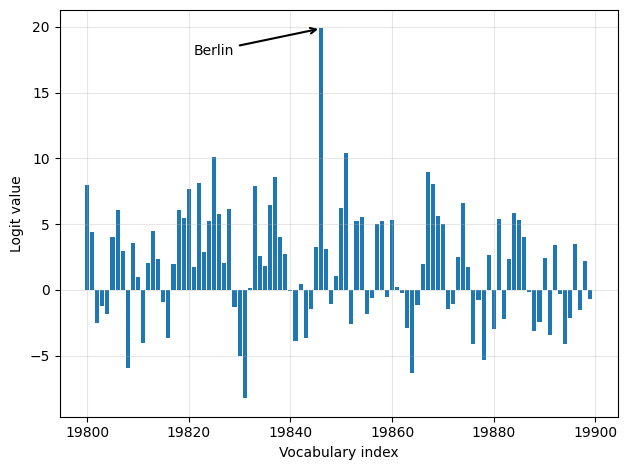

In [10]:
import matplotlib.pyplot as plt

def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    # Select vocabulary subsection
    x = torch.arange(start, end)

    # .cpu() is a shortcut for to(torch.device("cpu"))
    logits_section = next_token_logits[0, start:end].float().cpu()

    # Plot logits
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    # Highlight max logit
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scores_bar(next_token_logits)

&nbsp;
### 4.4.2 Rescaling token scores (logits) via a temperature parameter

Temperature, or, more precisely, the temperature parameter, rescales the logits, which makes the corresponding probability distribution sharper or flatter
and thereby affects how the next token is selected.

Rescaling here means adjusting
the magnitude of the scores so the sampling step becomes more or less sensitive to
differences in the scores.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F08_raschka.webp" width=600>

In [11]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

A temperature of 1.0
means no change, because dividing a number by 1 leaves it unchanged. A temperature lower than 1.0 makes the distribution sharper, which makes the model more confident
when it selects the next token. Temperatures higher than 1.0 flatten the logit distribution,
which can make sampling more diverse.

- Technically, it's better to use a bar plot, but lines make it easier to see the difference:

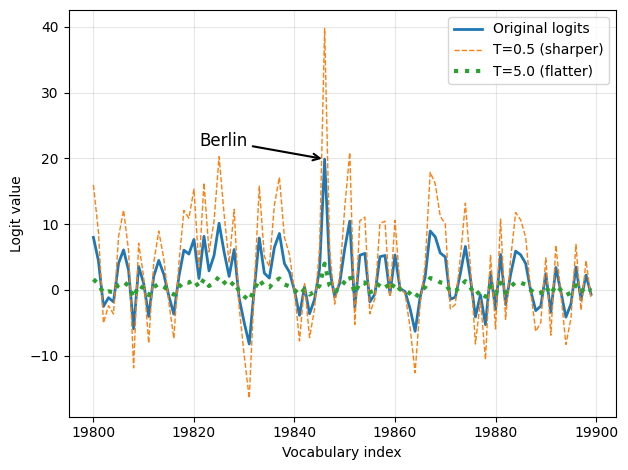

In [12]:
def plot_logits_with_temperature(
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    # Apply temperature scaling
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]
    # Plot logits
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )

    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

The important point is not the absolute height of a logit by itself, but how the differences
between logits change. If a token such as "Berlin" stands out more strongly than
the alternatives, it is more likely to be selected later. If the differences shrink, lower-ranked
tokens become more likely to be selected.

&nbsp;
### 4.4.3 Sampling the next token from a probability distribution

To demonstrate how rescaled logits are converted into probability scores, we’ll use a temperature of 5.0, which will make it easier to visualize the
resulting probabilities in a plot. The " Berlin" token, for example, has such a high logit
value that it would otherwise dominate the scale, making it difficult to see the probabilities
of the surrounding tokens.

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F10_raschka.webp" width=600>

In [14]:
# Step 3.2: Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# Step 3.3 Convert rescaled logits into probability scores
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

# the logit values to the range from 0 to 1, such that they sum to 1
print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., dtype=torch.bfloat16)


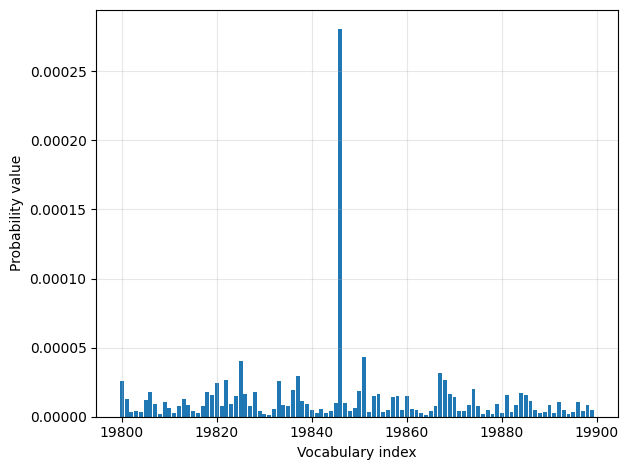

In [15]:
# Additionally, let’s visualize the converted scores
plot_scores_bar(
    next_token_probas, arrow=False, ylabel="Probability value"
)

In [16]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])

Token ID 19,846 probability: tensor([0.0003], dtype=torch.bfloat16)


In [17]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0003, dtype=torch.bfloat16)


In [18]:
# Step 3.4: Sample token according to probabilities
torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)
)

Sampled token: tensor([[65094]])


In [19]:
print(tokenizer.decode([65094]))

 mistress


In [20]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    # Draw samples according to probabilities
    samples = torch.multinomial(
        probas.cpu(), num_samples=num_samples, replacement=True
    )

    # Count how often each index was selected
    counts = torch.bincount(samples.squeeze(0), minlength=1)

    # Print results
    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

In [21]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

'|': 2x
' headquarters': 2x
'	register': 2x
'subscriber': 2x
' י': 2x
' Hà': 2x


In [22]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

'
': 2x
' __': 119x
' ___': 2x
' Berlin': 498x
' ____': 165x
' ______': 189x
' Munich': 5x
' Hamburg': 4x
' _____': 16x


In [23]:
print(probas_lowT[0, 19_846])

tensor(0.4961, dtype=torch.bfloat16)


- The `"______"` is likely because the model likely has seen formatting like this in the training set and tries to generate a quiz for the user

In [24]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.25), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 92x
' Berlin': 623x
' ____': 126x
' ______': 154x
' Munich': 2x
' _____': 3x


In [25]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.15), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 43x
' Berlin': 744x
' ____': 94x
' ______': 119x


In [26]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.05), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' Berlin': 1000x


Specifically, in reasoning tasks, we can use this sampling diversity through techniques
such as self-consistency, which generate multiple candidate
answers and compare them to improve answer accuracy.

&nbsp;
### 4.4.4 Adding temperature scaling to the text generation function

Let’s add the temperature-scaling modification to
the text generation function so we can more readily generate new tokens with the
model.

In [28]:
# Exercise 2.2 Appendix B
from rm_from_scratch.qwen3 import KVCache

@torch.inference_mode()
def generate_text_temp_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        ########################################
        # NEW:
        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        #########################################
        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [29]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 We begin with the equation \(\frac{1}{2}(3x - 9) = x + 37\).
First, distribute the \(\frac{1}{2}\) on the left-side of the equation to get \(3x - 9 = 2(x + 37)\).
Then simplify the right side of the equation by using the distributive property and combining like terms: \(3x - 9 = 2x + 74\).
Next, subtract \(2x\) from both sides of the equation to get \(x - 9 = 2x + 74\).
Next, subtract \(x\) from both sides of the equation to reduce the number of \(x\) terms on the right side to exactly 1: \(-9 = x + 74\).
Finally, subtract 74 from both sides of the equation to get \(x = -83\).
The value of \(x\) is \(\boxed{-83}\).

&nbsp;
## 4.5 Balancing diversity and coherence with top-p sampling

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F12_raschka.webp" width=600>

&nbsp;
### 4.5.1 Selecting a subset of top-p tokens

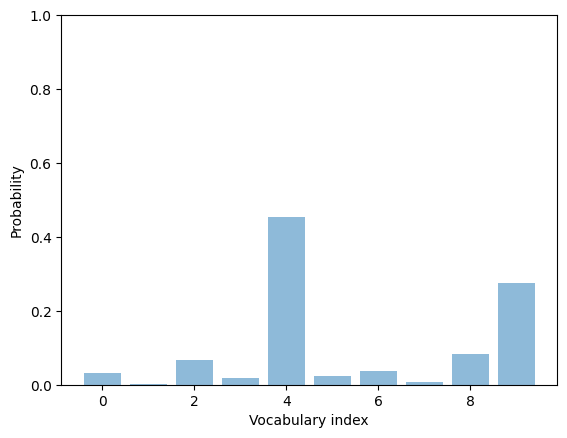

In [ ]:
# Step 3.1: Get logits (here: use toy logits for 10 tokens)
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

# Step 3.2: Apply temperature scaling
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Step 3.3: Convert to probabilities
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(
    torch.arange(len(toy_logits_scaled)), toy_probas,
    alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
# plt.savefig("12.pdf")
plt.show()

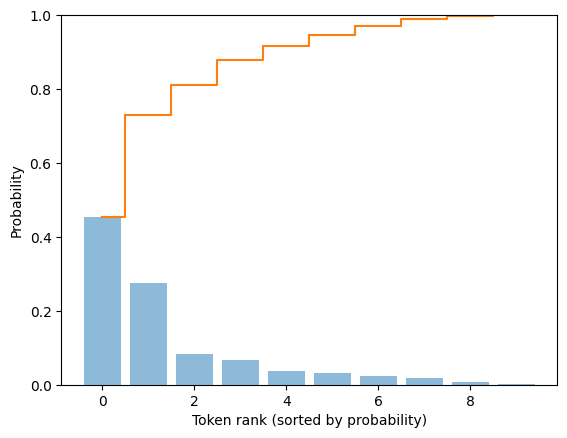

In [ ]:
# Step 4.1: Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas,
        alpha=0.5
)
plt.step(
    torch.arange(len(cumsum)), cumsum,
    where="mid", color="C1", label="Cumulative sum"
)

plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])

In [ ]:
# Step 4.3.1: Apply top-p threshold (e.g., keep tokens until cumulative mass > 0.8)
top_p = 0.8
keep_mask = cumsum <= top_p
n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2


In [ ]:
# A more common variant is to include the token that crosses the threshold
keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept:", n_kept)

Tokens kept: 3


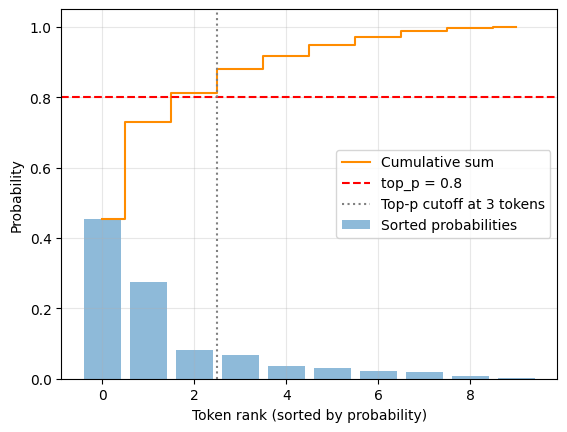

In [ ]:
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas,
    alpha=0.5, label="Sorted probabilities"
)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)

# Highlight cutoff
plt.axhline(
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)

plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
# plt.savefig("14.pdf")
plt.show()

In [ ]:
# Step 4.3.2: Zero out beyond cutoff
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)

# Step 4.3.3: Map back to original order
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)

print(filtered)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])


In [ ]:
# Step 4.4: Renormalize to sum to 1
denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
print(renormalized)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])


&nbsp;
### 4.5.2 Adding a top-p filter to the text generation function

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F16_raschka.webp" width=600>

In [ ]:
def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas

    # Step 4.1: Sort by descending probability
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)

    # Step 4.2: Cumulative sum
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # Step 4.3.1: Keep tokens where prefix cumulative mass (before token) is < top_p
    # Example: [0.5, 0.41, 0.09] with top_p=0.9 should keep the first two tokens
    prefix = cumprobas - sorted_probas   # cumulative mass before each token
    keep = prefix < top_p
    # Always keep at least one token (fallback for very small/non-positive top_p)
    keep[:, 0] = True

    # Step 4.3.2: Zero out beyond cutoff
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )
    # Step 4.3.3: Map back to original order
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Step 4.4: Renormalize to sum to 1
    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

In [ ]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [ ]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x


In [ ]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)

count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' Berlin': 534x
' ____': 217x
' ______': 249x


In [ ]:
@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.,
    top_p=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # (New) Step 4: Apply top-p filter to probabilities
            probas = top_p_filter(probas, top_p)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [ ]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8,
)

 \boxed{18}

&nbsp;
## 4.6 Improving response accuracy with self-consistency

- Generate multiple answers (/reasoning chains) via sampling and vote

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F17_raschka.webp" width=600>

- Similar to classic majority voting, but instead of different models, use different temperature settings
- This method is also described in the [Self-Consistency Improves Chain-of-Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171) paper
- In short, this method
  - Samples multiple reasoning chains with high temperature and top-p
  - Extracts the final answer from each chain
  - Chooses the most frequent final answer
- Nit: this is called [plurality vote](https://en.wikipedia.org/wiki/Plurality_(voting)) (in American English), not majority vote

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F18_raschka.webp?1" width=600>

In [ ]:
from reasoning_from_scratch.ch03 import extract_final_candidate
from collections import Counter

def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9, max_new_tokens=2048,
    show_progress=True, show_long_answer=False, seed=None,
):
    full_answers, short_answers = [], []

    # 1) Sample multiple answers
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt, device=device,
            max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, top_p=top_p,
        )

        # 2) Extract the final (short) answer from each answer
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")

    # 3) Choose the most frequent final answer (self-consistency vote)
    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)

    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None

    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

- Additional tips
  - If all (long) answers look nearly identical, increase temperature gently to increase diversity  
  - If (long) answers look off, decrease temperature

In [ ]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '22'
[Sample 3/5] → '54'
[Sample 4/5] → '83'
[Sample 5/5] → '61'


In [ ]:
print(results["final_answer"])

83


In [ ]:
print(results["full_answers"][0])

 To find the value of \( x \), let's solve the equation step by step.

1. **Given Equation:**
   \[
   \frac{1}{2} \times (3x - 9) = x + 37
   \]

2. **Multiply Both Sides by 2 to Eliminate the Fraction:**
   \[
   2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
   \]
   \[
   3x - 9 = 2x + 74
   \]

3. **Subtract \( 2x \) from Both Sides to Get:**
   \[
   3x - 2x - 9 = 74
   \]
   \[
   x - 9 = 74
   \]

4. **Add 9 to Both Sides to Solve for \( x \):**
   \[
   x = 74 + 9
   \]
   \[
   x = 83
   \]

**Final Answer:**
\[
\boxed{83}
\]


In [ ]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → 'x = 83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


- Parallel sampling like this is also done by Claude 4 (https://www.anthropic.com/news/claude-4); in addition, Claude 4 uses an internal model for scoring responses
- A scorer can be similar to the LLM judge in Appendix F (F.5 Judging responses with other LLMs)
- In the next chapter, we will also introduce a scoring method based on confidence scores (we can also use it as a tie-breaker)

Below are the results of the different methods on a cuda device (DGX Spark) evaluated on the full MATH-500 test set with all 500 problems

|    | Method                                       | Model     | Accuracy | Time       |
|----|----------------------------------------------|-----------|----------|------------|
| 1  | Baseline (chapter 3), greedy decoding        | Base      | 15.2%    | 10.1 min   |
| 2  | Baseline (chapter 3), greedy decoding        | Reasoning | 48.2%    | 182.1 min  |
| 3  | Chain-of-thought prompting ("CoT")           | Base      | 40.6%    | 84.5 min   |
| 4  | Temperature and top-p ("Top-p")              | Base      | 17.8%    | 30.7 min   |
| 5  | "Top-p" + Self-consistency (n=3)             | Base      | 29.6%    | 97.6 min   |
| 6  | "Top-p" + Self-consistency (n=5)             | Base      | 27.8%    | 116.8 min  |
| 7  | "Top-p" + Self-consistency (n=10)            | Base      | 31.6%    | 300.4 min  |
| 8  | "Top-p" + "CoT"                              | Base      | 33.4%    | 129.2 min  |
| 9  | Self-consistency (n=3) + "Top-p" + "CoT"     | Base      | 42.2%    | 211.6 min  |
| 10 | Self-consistency (n=5) + "Top-p" + "CoT"     | Base      | 48.0%    | 452.9 min  |
| 11 | Self-consistency (n=10) + "Top-p" + "CoT"    | Base      | 52.0%    | 862.6 min  |
| 12 | Self-consistency (n=3) + "Top-p" + "CoT"     | Reasoning | 55.2%    | 544.4 min  |

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F19_raschka.webp" width=600>

&nbsp;
## 4.7 Summary

- No code in this section